# Technical Indicators

Technical indicators transform price and volume data into trend, momentum, and volatility signals.

Abbreviations used in this notebook:

- **SMA**: Simple Moving Average.
- **EMA**: Exponential Moving Average.
- **RSI**: Relative Strength Index.
- **RS**: Relative Strength, average gain divided by average loss inside RSI.
- **MACD**: Moving Average Convergence Divergence.
- **ATR**: Average True Range.
- **OHLCV**: Open, High, Low, Close, Volume.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

Indicators are summaries of market behavior. Moving averages smooth price trends, RSI measures recent gains versus losses, MACD compares short and long trend momentum, and ATR approximates daily trading range volatility.

Indicators do not create information from nowhere. They repackage price and volume history into features that are easier to compare and test.

## 2. Mathematics

Simple moving average:

$$
SMA_n = \frac{1}{n}\sum_{i=0}^{n-1} Close_{t-i}
$$

Exponential moving average:

$$
EMA_t = \alpha Close_t + (1 - \alpha)EMA_{t-1}
$$

RSI:

$$
RSI = 100 - \frac{100}{1 + RS}
$$

MACD:

$$
MACD = EMA_{12} - EMA_{26}
$$

Average true range uses the average of true range:

$$
TR_t = \max(High_t - Low_t, |High_t - Close_{t-1}|, |Low_t - Close_{t-1}|)
$$

## 3. Implementation

We generate synthetic OHLCV data and compute common indicators using pandas rolling and exponential-weighted functions.

In [3]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "02_market_data" / "data_pipeline" / "fetch_data.py"
spec = importlib.util.spec_from_file_location("market_data_fetch_data", helper_path)
fetch_data = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fetch_data)

add_return_columns = fetch_data.add_return_columns
generate_synthetic_ohlcv = fetch_data.generate_synthetic_ohlcv

plt.style.use("seaborn-v0_8-whitegrid")

data = add_return_columns(generate_synthetic_ohlcv(ticker="NESN.SW", periods=220, seed=22))

data["sma_20"] = data["close"].rolling(20).mean()
data["sma_50"] = data["close"].rolling(50).mean()
data["ema_12"] = data["close"].ewm(span=12, adjust=False).mean()
data["ema_26"] = data["close"].ewm(span=26, adjust=False).mean()
data["macd"] = data["ema_12"] - data["ema_26"]
data["macd_signal"] = data["macd"].ewm(span=9, adjust=False).mean()

delta = data["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
data["rsi_14"] = 100 - (100 / (1 + rs))

previous_close = data["close"].shift(1)
true_range = pd.concat([
    data["high"] - data["low"],
    (data["high"] - previous_close).abs(),
    (data["low"] - previous_close).abs(),
], axis=1).max(axis=1)
data["atr_14"] = true_range.rolling(14).mean()

data.tail()

,date,ticker,open,high,low,close,volume,simple_return,log_return,traded_value,sma_20,sma_50,ema_12,ema_26,macd,macd_signal,rsi_14,atr_14
215,2024-10-29,NESN.SW,118.043807,118.598728,117.101042,118.441722,4131610,-0.003381,-0.003387,4.893550e+08,118.966604,121.407440,119.221274,119.736532,-0.515259,-0.648286,43.606134,1.808921
216,2024-10-30,NESN.SW,117.816638,118.795995,116.786907,117.476923,2604674,-0.008146,-0.008179,3.059891e+08,118.953414,121.301755,118.952912,119.569154,-0.616242,-0.641878,38.165504,1.766082
217,2024-10-31,NESN.SW,116.948704,117.221845,115.874918,116.599137,4167696,-0.007472,-0.007500,4.859498e+08,118.855414,121.199185,118.590793,119.349153,-0.758360,-0.665174,39.233320,1.706790
218,2024-11-01,NESN.SW,116.583250,116.924214,115.735515,116.415582,1634506,-0.001574,-0.001575,1.902820e+08,118.731007,121.064577,118.256145,119.131851,-0.875706,-0.707280,35.160185,1.700265
219,2024-11-04,NESN.SW,119.184871,120.191289,118.369926,119.202306,1343170,0.023938,0.023656,1.601090e+08,118.763792,120.941575,118.401708,119.137070,-0.735362,-0.712897,54.102463,1.885573


In [4]:
latest = data.iloc[-1]
indicator_snapshot = pd.Series({
    "latest_close": latest["close"],
    "sma_20": latest["sma_20"],
    "sma_50": latest["sma_50"],
    "rsi_14": latest["rsi_14"],
    "macd": latest["macd"],
    "macd_signal": latest["macd_signal"],
    "atr_14": latest["atr_14"],
})

indicator_snapshot.to_frame("value")

,value
latest_close,119.202306
sma_20,118.763792
sma_50,120.941575
rsi_14,54.102463
macd,-0.735362
macd_signal,-0.712897
atr_14,1.885573


## 4. Visualization

Indicator charts should make the signal visible without hiding the underlying price data.

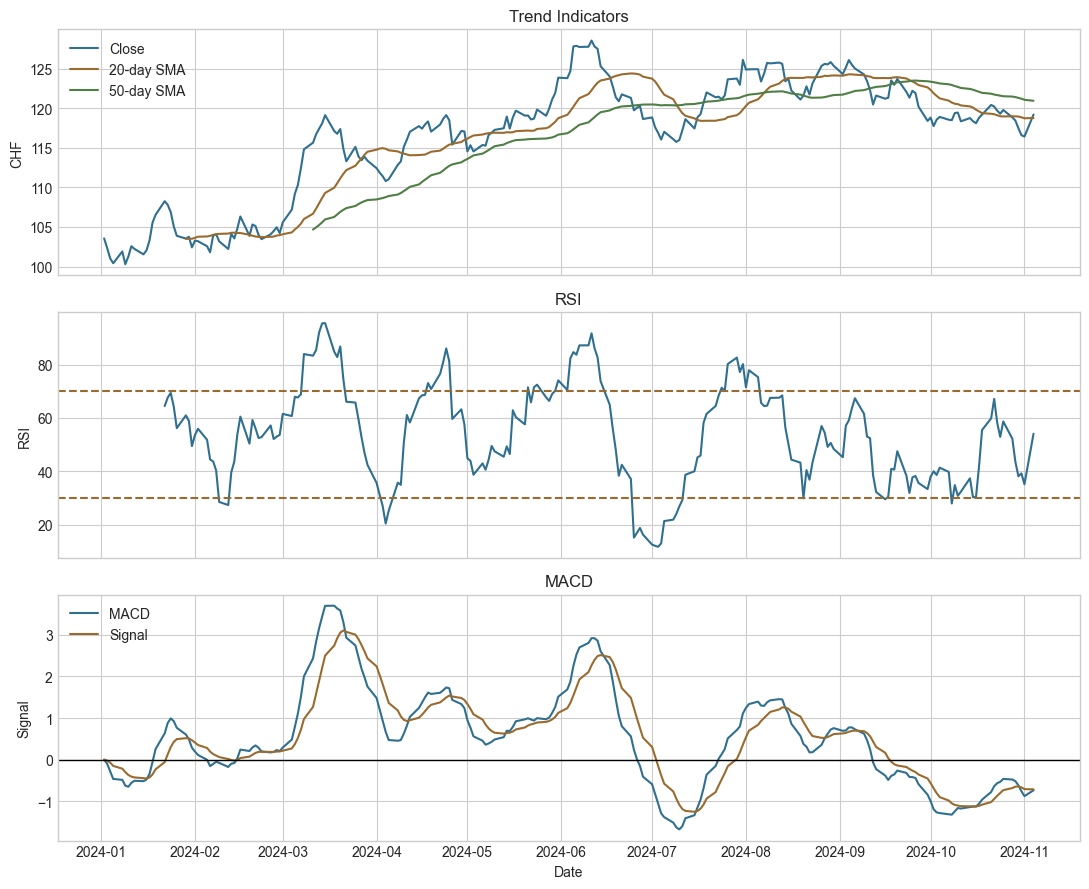

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(data["date"], data["close"], color="#2f6f8f", label="Close")
axes[0].plot(data["date"], data["sma_20"], color="#9a6b2f", label="20-day SMA")
axes[0].plot(data["date"], data["sma_50"], color="#4f7f45", label="50-day SMA")
axes[0].set_title("Trend Indicators")
axes[0].set_ylabel("CHF")
axes[0].legend(loc="upper left")

axes[1].plot(data["date"], data["rsi_14"], color="#2f6f8f")
axes[1].axhline(70, color="#9a6b2f", linestyle="--")
axes[1].axhline(30, color="#9a6b2f", linestyle="--")
axes[1].set_title("RSI")
axes[1].set_ylabel("RSI")

axes[2].plot(data["date"], data["macd"], color="#2f6f8f", label="MACD")
axes[2].plot(data["date"], data["macd_signal"], color="#9a6b2f", label="Signal")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("MACD")
axes[2].set_ylabel("Signal")
axes[2].set_xlabel("Date")
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

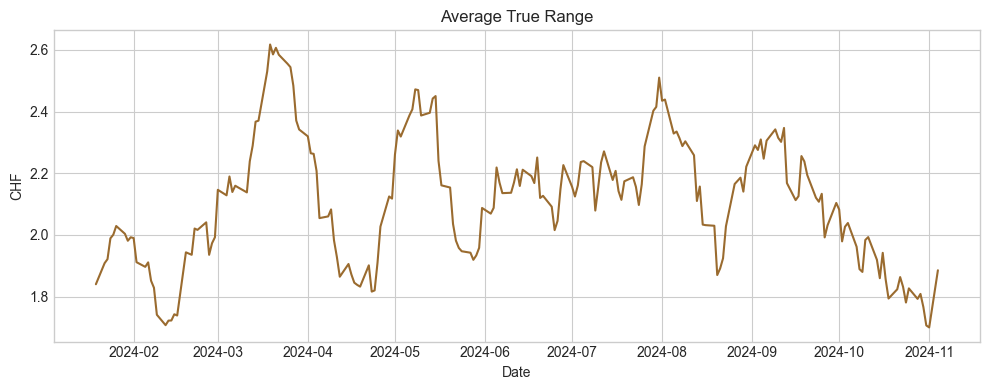

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(data["date"], data["atr_14"], color="#9a6b2f")
ax.set_title("Average True Range")
ax.set_xlabel("Date")
ax.set_ylabel("CHF")
plt.tight_layout()
plt.show()

## 5. Application

Indicators can be used as model features, screening tools, or backtest rules. A simple example is a trend label based on whether the short moving average is above the long moving average.

In [7]:
signals = data.dropna().copy()
signals["trend_signal"] = np.where(signals["sma_20"] > signals["sma_50"], 1, 0)
signals["next_day_return"] = signals["simple_return"].shift(-1)

signal_summary = signals.groupby("trend_signal")["next_day_return"].agg(["count", "mean", "std"])
signal_summary.index = ["Below/flat trend", "Above trend"]
signal_summary

,count,mean,std
Below/flat trend,49,0.001179,0.009012
Above trend,121,-0.000168,0.009269


## 6. Reflection

- Indicators are transformations of historical price and volume data.
- Trend and momentum indicators can lag because they use past prices.
- Indicator rules should be tested out of sample before being trusted.
- A signal is not a strategy until costs, risk, and execution are included.

Questions to answer after running the notebook:

1. Why do moving averages lag price?
2. What does RSI try to measure?
3. Why can an indicator look useful on a chart but fail in a backtest?
4. Which indicator would you test first in a systematic strategy?